In [1]:
import pandas as pd # importing pandas for  handling and data manuplation
import numpy as np  #importing numpy for mathematical operation
import matplotlib.pyplot as plt #for data visualisation
import seaborn as sns   #for data visualisation
from sklearn.model_selection import train_test_split #  splitting the dataset into traning and test sets
from sklearn.ensemble import RandomForestClassifier  #machine learning model for classification
from sklearn.metrics import accuracy_score , classification_report    #TO eevaluate model performance
     

In [3]:
df = pd.read_csv("/Users/amoghmothukuri/Desktop/customer_support_data.csv")

In [5]:
# Converting date columns into datetime format

date_cols = ["order_date_time", "Issue_reported at", "issue_responded", "Survey_response_Date"]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=True)

In [9]:
# Fill missing values in Customer Remarks
df['Customer Remarks'] = df['Customer Remarks'].fillna("No Remarks")

# Fill missing values in Item_price with median
df['Item_price'] = df['Item_price'].fillna(df['Item_price'].median())

df.drop(columns=['Customer_City', 'connected_handling_time'], errors='ignore', inplace=True)

In [10]:
df['Customer Remarks'] = df['Customer Remarks'].fillna("No Remarks")    
df['Item_price'] = df['Item_price'].fillna(df['Item_price'].median())  

In [11]:
if 'Customer_City' in df.columns:
    df.drop(columns=['Customer_City'], inplace=True)  # Too many missing values
if 'connected_handling_time' in df.columns:
    df.drop(columns=['connected_handling_time'], inplace=True)

In [12]:
#Feature enginnering
#Calculating Response time

df["response_time"] = (df["issue_responded"] - df["Issue_reported at"]).dt.total_seconds()
df["response_time"] = df["response_time"].fillna(df["response_time"].median())
     

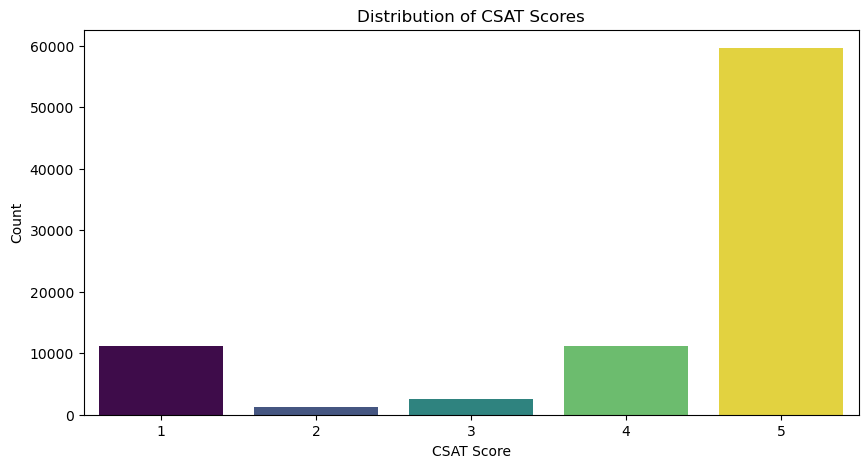

In [14]:
# For CSAT Score distribution
plt.figure(figsize=(10,5))

sns.countplot(x="CSAT Score", data=df, hue="CSAT Score", palette="viridis", legend=False)

plt.title("Distribution of CSAT Scores")
plt.xlabel("CSAT Score")
plt.ylabel("Count")

plt.show()

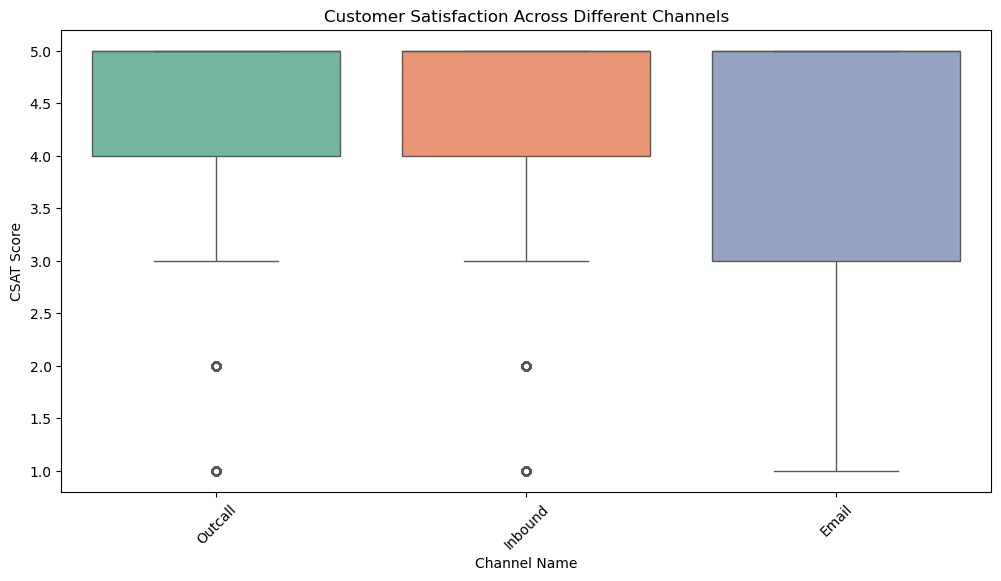

In [16]:
# Satisfaction across different support channels

plt.figure(figsize=(12,6))

sns.boxplot(
    x="channel_name",
    y="CSAT Score",
    data=df,
    hue="channel_name",
    palette="Set2",
    legend=False
)

plt.xticks(rotation=45)
plt.xlabel("Channel Name")
plt.ylabel("CSAT Score")
plt.title("Customer Satisfaction Across Different Channels")

plt.show()

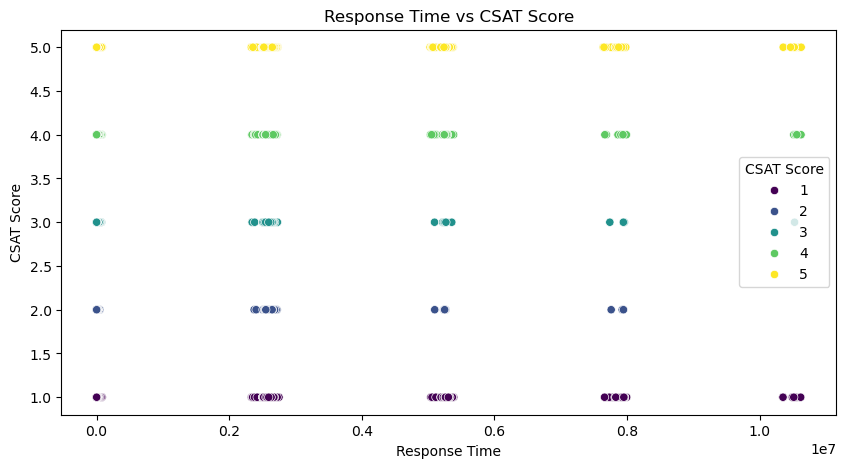

In [17]:
# Comparing Response Time vs CSAT Score

plt.figure(figsize=(10,5))

sns.scatterplot(
    x="response_time",
    y="CSAT Score",
    data=df,
    hue="CSAT Score",
    palette="viridis"
)

plt.xlabel("Response Time")
plt.ylabel("CSAT Score")
plt.title("Response Time vs CSAT Score")

plt.show()


In [18]:
# Selecting relevant features for prediction
features = ["response_time", "Item_price", "channel_name", "category", "Tenure Bucket", "Agent Shift"]

# Creating modeling dataframe
df_model = df[features + ["CSAT Score"]]

# One-hot encoding for categorical variables
df_model = pd.get_dummies(df_model, drop_first=True)


In [19]:
#Spitting Data Into Train and Test Sets
X = df_model.drop(columns=['CSAT Score'])
y = df_model['CSAT Score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [20]:
model = RandomForestClassifier(n_estimators = 100 , random_state = 42)
model.fit(X_train , y_train)
     

RandomForestClassifier(random_state=42)

In [21]:
y_pred = model.predict(X_test)

In [22]:
print("Model Accuracy:" , accuracy_score(y_test , y_pred))
print(classification_report(y_test , y_pred))

Model Accuracy: 0.654172971714585
              precision    recall  f1-score   support

           1       0.24      0.09      0.13      2241
           2       0.01      0.00      0.01       227
           3       0.05      0.01      0.02       503
           4       0.13      0.03      0.05      2277
           5       0.70      0.92      0.80     11934

    accuracy                           0.65     17182
   macro avg       0.23      0.21      0.20     17182
weighted avg       0.54      0.65      0.58     17182

